# Figure 4. OpenXAI-inspired Explanation Reliability Analysis

This notebook generates a 170 mm-wide publication-style Figure 4 for ICU mortality explanation reliability.

**Models**
- Logistic Regression
- Linear SVM
- XGBoost

**Panels**
- **a)** Cross-fold explanation stability
- **b)** False explanation stress test using Gaussian noise, permuted-feature noise, and spurious proxy features
- **c)** Agreement across explanation methods
- **d)** Clinical-domain composition / false-inference audit

Run this notebook from the `OpenXAI/code/` folder, with data stored in `OpenXAI/data/`.

**Important note:** the false-signal stress-test parameters are intentionally placed in the global settings cell and commented in English so you can easily adjust the number and strength of injected features.


In [1]:
# ============================================================
# Figure 4. OpenXAI-inspired explanation reliability analysis
# Models: Logistic Regression, Linear SVM, XGBoost
#
# Recommended folder structure:
#   OpenXAI/
#   ├── data/
#   │   ├── X_train.csv
#   │   ├── X_test.csv
#   │   ├── y_train.csv
#   │   ├── y_test.csv
#   │   └── cohort_distribution_dataset.csv
#   └── code/
#       └── make_figure4_explanation_reliability.ipynb
# ============================================================

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBClassifier
except ImportError as e:
    raise ImportError(
        "xgboost is required. Install with: pip install xgboost"
    ) from e

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("WARNING: shap is not installed. XGBoost explanation will fall back to feature_importances_.")


In [2]:
# ============================================================
# 0. Global settings
# ============================================================

RANDOM_SEED = 42
TOP_K = 20
CV_FOLDS = 5

# ------------------------------------------------------------
# Adjustable false-signal stress-test settings
# ------------------------------------------------------------
# These settings control how difficult the false-explanation stress test is.
#
# N_GAUSSIAN_NOISE:
#   Number of pure random Gaussian features added to the dataset.
#   These are the easiest negative-control features. A reliable explanation
#   method should almost never rank them in the top-k features.
#
# N_PERMUTED_NOISE:
#   Number of permuted real-feature controls. These preserve the marginal
#   distribution of real ICU variables but break their relationship with the label.
#   This is a stronger negative control than Gaussian noise.
#
# N_SPURIOUS_PROXY:
#   Number of artificial train-only proxy features. These are intentionally
#   correlated with the training labels but random in the external/test cohort.
#   They act as a positive-control false signal for testing whether explanations
#   can expose spurious associations learned during training.
#
# SPURIOUS_SIGNAL_STRENGTH:
#   Controls how strongly the spurious proxy features correlate with y_train.
#   Higher values make the stress test more difficult.
#   Recommended range: 0.50 to 0.95.
#
# N_NOISE_REPEATS:
#   Number of repeated stress-test runs with different random seeds.
#   Increase this for more stable estimates, but runtime will increase.
N_GAUSSIAN_NOISE = 50
N_PERMUTED_NOISE = 50
N_SPURIOUS_PROXY = 20
SPURIOUS_SIGNAL_STRENGTH = 0.85
N_NOISE_REPEATS = 10

# Explanation sampling setting to reduce runtime
EXPLAIN_N = 1500
PERMUTATION_N = 1500
PERMUTATION_REPEATS = 5

# PNAS-style publication sizing
FIG_WIDTH_MM = 170
FIG_HEIGHT_MM = 145

# If notebook is inside OpenXAI/code, this works.
DATA_DIR = Path("../data")
OUT_DIR = Path("../figures/Figure4")
RESULT_DIR = Path("../results/Figure4")

OUT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

FIG_PNG = OUT_DIR / "Figure4_explanation_reliability_170mm.png"
FIG_PDF = OUT_DIR / "Figure4_explanation_reliability_170mm.pdf"

print("DATA_DIR:", DATA_DIR.resolve())
print("OUT_DIR:", OUT_DIR.resolve())
print("RESULT_DIR:", RESULT_DIR.resolve())


DATA_DIR: C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\data
OUT_DIR: C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\figures\Figure4
RESULT_DIR: C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\results\Figure4


In [3]:
# ============================================================
# 1. Load data
# ============================================================

def find_file(data_dir, expected_name):
    """
    Finds an expected CSV file.
    First tries exact name, then falls back to a prefix match such as X_train*.csv.
    This helps if the downloaded file is named like X_train(10).csv.
    """
    exact = data_dir / expected_name
    if exact.exists():
        return exact

    stem = expected_name.replace(".csv", "")
    matches = sorted(data_dir.glob(f"{stem}*.csv"))
    if matches:
        print(f"Using {matches[0].name} for expected file {expected_name}")
        return matches[0]

    raise FileNotFoundError(f"Cannot find {expected_name} or {stem}*.csv in {data_dir.resolve()}")


def clean_columns(df):
    df = df.copy()
    df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]
    return df


def read_y(path):
    df = clean_columns(pd.read_csv(path))

    preferred_cols = [
        "in_hospital_death",
        "In-hospital_death",
        "InHospitalDeath",
        "mortality",
        "death",
        "label",
        "target",
        "y",
    ]

    for c in preferred_cols:
        if c in df.columns:
            return df[c].astype(int)

    if df.shape[1] == 1:
        return df.iloc[:, 0].astype(int)

    raise ValueError(
        f"Could not identify label column in {path}. "
        f"Columns found: {list(df.columns)}"
    )


def drop_leakage_columns(X):
    X = X.copy()

    leakage_names = {
        "recordid",
        "record_id",
        "in_hospital_death",
        "inhospitaldeath",
        "survival",
        "length_of_stay",
        "lengthofstay",
        "saps-i",
        "saps_i",
        "sofa",
    }

    drop_cols = []
    for c in X.columns:
        c_norm = str(c).lower().replace(" ", "_")
        if c_norm in leakage_names:
            drop_cols.append(c)

    if drop_cols:
        print("Dropping possible leakage/id columns:", drop_cols)
        X = X.drop(columns=drop_cols)

    return X


X_train_path = find_file(DATA_DIR, "X_train.csv")
X_test_path = find_file(DATA_DIR, "X_test.csv")
y_train_path = find_file(DATA_DIR, "y_train.csv")
y_test_path = find_file(DATA_DIR, "y_test.csv")

X_train = clean_columns(pd.read_csv(X_train_path))
X_test = clean_columns(pd.read_csv(X_test_path))
y_train = read_y(y_train_path)
y_test = read_y(y_test_path)

X_train = drop_leakage_columns(X_train)
X_test = drop_leakage_columns(X_test)

common_cols = [c for c in X_train.columns if c in X_test.columns]
X_train = X_train[common_cols].copy()
X_test = X_test[common_cols].copy()

X_train = X_train.apply(pd.to_numeric, errors="coerce")
X_test = X_test.apply(pd.to_numeric, errors="coerce")

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)
print("y_train mortality rate:", float(np.mean(y_train)))
print("y_test mortality rate :", float(np.mean(y_test)))

display(X_train.head())


X_train: (8000, 243)
X_test : (4000, 243)
y_train: (8000,)
y_test : (4000,)
y_train mortality rate: 0.14025
y_test mortality rate : 0.14625


,BUN_count,BUN_first,BUN_last,BUN_max,BUN_mean,BUN_median,BUN_min,BUN_missing,BUN_std,Creatinine_count,...,pH_mean,pH_median,pH_min,pH_missing,pH_std,static_Age,static_Gender,static_Height,static_ICUType,static_Weight
0,2.0,13.0,8.0,13.0,10.500000,10.5,8.0,0.0,3.535534,2.0,...,7.45267,7.420371,7.341433,1.0,0.171855,54.0,0.0,169.724569,4.0,81.51839
1,3.0,16.0,21.0,21.0,18.333333,18.0,16.0,0.0,2.516611,3.0,...,7.39500,7.400000,7.340000,0.0,0.037796,76.0,1.0,175.300000,2.0,76.00000
2,3.0,8.0,3.0,8.0,4.666667,3.0,3.0,0.0,2.886751,3.0,...,7.49500,7.500000,7.470000,0.0,0.017321,44.0,0.0,169.724569,3.0,56.70000
3,3.0,23.0,10.0,23.0,17.666667,20.0,10.0,0.0,6.806859,3.0,...,7.45267,7.420371,7.341433,1.0,0.171855,68.0,1.0,180.300000,3.0,84.60000
4,2.0,45.0,25.0,45.0,35.000000,35.0,25.0,0.0,14.142136,2.0,...,7.45267,7.420371,7.341433,1.0,0.171855,88.0,0.0,169.724569,3.0,81.51839


In [4]:
# ============================================================
# 2. Helper functions
# ============================================================

def top_k_features(importance, k=TOP_K):
    return list(importance.sort_values(ascending=False).head(k).index)


def jaccard(a, b):
    a = set(a)
    b = set(b)
    if len(a | b) == 0:
        return np.nan
    return len(a & b) / len(a | b)


def pairwise_jaccard_mean(top_sets):
    values = []
    for i in range(len(top_sets)):
        for j in range(i + 1, len(top_sets)):
            values.append(jaccard(top_sets[i], top_sets[j]))
    return float(np.nanmean(values)), float(np.nanstd(values)), values


def stratified_sample_indices(y, max_n, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    y_arr = np.asarray(y)

    if len(y_arr) <= max_n:
        return np.arange(len(y_arr))

    idx_all = []
    classes, counts = np.unique(y_arr, return_counts=True)

    for cls, count in zip(classes, counts):
        cls_idx = np.where(y_arr == cls)[0]
        n_cls = int(round(max_n * count / len(y_arr)))
        n_cls = max(1, min(n_cls, len(cls_idx)))
        idx_all.extend(rng.choice(cls_idx, size=n_cls, replace=False).tolist())

    idx_all = np.array(idx_all)

    if len(idx_all) > max_n:
        idx_all = rng.choice(idx_all, size=max_n, replace=False)

    rng.shuffle(idx_all)
    return idx_all


def get_scale_pos_weight(y):
    y = np.asarray(y)
    pos = np.sum(y == 1)
    neg = np.sum(y == 0)
    if pos == 0:
        return 1.0
    return neg / pos


def make_xgb(seed=RANDOM_SEED, scale_pos_weight=1.0):
    return XGBClassifier(
        n_estimators=250,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=seed,
        n_jobs=-1,
    )


In [5]:
# ============================================================
# 3. Model-specific explanation functions
# ============================================================

def logistic_importance(X_tr, y_tr):
    pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    penalty="l2",
                    C=1.0,
                    solver="liblinear",
                    class_weight="balanced",
                    max_iter=5000,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )

    pipe.fit(X_tr, y_tr)
    coefs = np.abs(pipe.named_steps["model"].coef_[0])
    return pd.Series(coefs, index=X_tr.columns).sort_values(ascending=False)


def svm_importance(X_tr, y_tr):
    pipe = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            (
                "model",
                LinearSVC(
                    C=1.0,
                    class_weight="balanced",
                    max_iter=20000,
                    dual=False,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]
    )

    pipe.fit(X_tr, y_tr)
    coefs = np.abs(pipe.named_steps["model"].coef_[0])
    return pd.Series(coefs, index=X_tr.columns).sort_values(ascending=False)


def xgb_shap_importance(X_tr, y_tr, X_eval, seed=RANDOM_SEED):
    imputer = SimpleImputer(strategy="median")
    X_tr_imp = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index,
    )
    X_eval_imp = pd.DataFrame(
        imputer.transform(X_eval),
        columns=X_eval.columns,
        index=X_eval.index,
    )

    model = make_xgb(
        seed=seed,
        scale_pos_weight=get_scale_pos_weight(y_tr),
    )
    model.fit(X_tr_imp, y_tr)

    idx = stratified_sample_indices(
        np.zeros(len(X_eval_imp)),
        max_n=min(EXPLAIN_N, len(X_eval_imp)),
        seed=seed,
    )
    X_exp = X_eval_imp.iloc[idx]

    if HAS_SHAP:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_exp)

        if isinstance(shap_values, list):
            shap_values = shap_values[-1]

        shap_values = np.asarray(shap_values)

        if shap_values.ndim == 3:
            shap_values = shap_values[:, :, -1]

        vals = np.mean(np.abs(shap_values), axis=0)
        return pd.Series(vals, index=X_tr.columns).sort_values(ascending=False)

    vals = model.feature_importances_
    return pd.Series(vals, index=X_tr.columns).sort_values(ascending=False)


def xgb_permutation_importance(X_tr, y_tr, X_eval, y_eval, seed=RANDOM_SEED):
    imputer = SimpleImputer(strategy="median")
    X_tr_imp = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index,
    )
    X_eval_imp = pd.DataFrame(
        imputer.transform(X_eval),
        columns=X_eval.columns,
        index=X_eval.index,
    )

    model = make_xgb(
        seed=seed,
        scale_pos_weight=get_scale_pos_weight(y_tr),
    )
    model.fit(X_tr_imp, y_tr)

    idx = stratified_sample_indices(
        y_eval,
        max_n=min(PERMUTATION_N, len(X_eval_imp)),
        seed=seed,
    )

    X_perm = X_eval_imp.iloc[idx]
    y_perm = np.asarray(y_eval)[idx]

    result = permutation_importance(
        model,
        X_perm,
        y_perm,
        scoring="roc_auc",
        n_repeats=PERMUTATION_REPEATS,
        random_state=seed,
        n_jobs=-1,
    )

    vals = np.maximum(result.importances_mean, 0)
    return pd.Series(vals, index=X_tr.columns).sort_values(ascending=False)


def compute_importance(model_name, X_tr, y_tr, X_eval=None, y_eval=None, seed=RANDOM_SEED):
    if model_name == "Logistic Regression":
        return logistic_importance(X_tr, y_tr)

    if model_name == "Linear SVM":
        return svm_importance(X_tr, y_tr)

    if model_name == "XGBoost":
        if X_eval is None:
            X_eval = X_tr
        return xgb_shap_importance(X_tr, y_tr, X_eval, seed=seed)

    if model_name == "XGBoost Permutation":
        if X_eval is None or y_eval is None:
            raise ValueError("XGBoost Permutation requires X_eval and y_eval.")
        return xgb_permutation_importance(X_tr, y_tr, X_eval, y_eval, seed=seed)

    raise ValueError(f"Unknown model_name: {model_name}")


In [6]:
# ============================================================
# 4. Panel A: explanation stability across CV folds
# Fixed version: avoid SHAP crash for XGBoost CV stability
# ============================================================

models_main = ["Logistic Regression", "Linear SVM", "XGBoost"]

def xgb_builtin_gain_importance(X_tr, y_tr, seed=RANDOM_SEED):
    """
    Safe fallback for XGBoost feature importance.
    This avoids shap.TreeExplainer errors caused by some SHAP/XGBoost version mismatches.
    """
    imputer = SimpleImputer(strategy="median")

    X_tr_imp = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index,
    )

    model = make_xgb(
        seed=seed,
        scale_pos_weight=get_scale_pos_weight(y_tr),
    )
    model.fit(X_tr_imp, y_tr)

    booster = model.get_booster()
    score_dict = booster.get_score(importance_type="gain")

    importance = pd.Series(0.0, index=X_tr.columns)

    for key, value in score_dict.items():
        # XGBoost sometimes returns feature names directly,
        # but sometimes returns f0, f1, f2...
        if key in importance.index:
            importance.loc[key] = value
        elif key.startswith("f") and key[1:].isdigit():
            idx = int(key[1:])
            if idx < len(X_tr.columns):
                importance.iloc[idx] = value

    return importance.sort_values(ascending=False)


def safe_compute_cv_importance(model_name, X_tr, y_tr, X_eval=None, seed=RANDOM_SEED):
    """
    For LR and SVM, use the original compute_importance().
    For XGBoost, use built-in gain importance for CV stability to avoid SHAP version errors.
    """
    if model_name == "XGBoost":
        return xgb_builtin_gain_importance(X_tr, y_tr, seed=seed)

    return compute_importance(
        model_name=model_name,
        X_tr=X_tr,
        y_tr=y_tr,
        X_eval=X_eval,
        seed=seed,
    )


stability_rows = []
cv_topsets = {}

skf = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_SEED,
)

for model_name in models_main:
    print(f"\nComputing CV stability for {model_name}...")
    fold_sets = []

    for fold_id, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
        X_tr = X_train.iloc[tr_idx]
        y_tr = y_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]

        importance = safe_compute_cv_importance(
            model_name=model_name,
            X_tr=X_tr,
            y_tr=y_tr,
            X_eval=X_val,
            seed=RANDOM_SEED + fold_id,
        )

        fold_sets.append(top_k_features(importance, TOP_K))

    mean_j, std_j, all_j = pairwise_jaccard_mean(fold_sets)

    stability_rows.append(
        {
            "model": model_name,
            "stability_mean": mean_j,
            "stability_std": std_j,
            "n_pairwise_fold_comparisons": len(all_j),
        }
    )

    cv_topsets[model_name] = fold_sets

stability_df = pd.DataFrame(stability_rows)
stability_df.to_csv(RESULT_DIR / "figure4_panelA_stability.csv", index=False)
display(stability_df)


Computing CV stability for Logistic Regression...

Computing CV stability for Linear SVM...

Computing CV stability for XGBoost...


,model,stability_mean,stability_std,n_pairwise_fold_comparisons
0,Logistic Regression,0.427602,0.076525,10
1,Linear SVM,0.427159,0.071459,10
2,XGBoost,0.416535,0.065411,10


In [7]:
# ============================================================
# 5. Panel B + D: false explanation stress test and domain composition
# Fixed version: avoid SHAP crash for XGBoost noise/spurious tests
# ============================================================

STRESS_TYPES = ["Gaussian noise", "Permuted feature", "Spurious proxy"]


def add_stress_test_features(X_tr, y_tr, X_eval, stress_type, seed=RANDOM_SEED):
    """
    Add one type of injected false-signal feature family.

    Gaussian noise:
        Pure random N(0, 1) features in train and test.

    Permuted feature:
        Real ICU feature values are randomly permuted, preserving the marginal
        distribution while breaking patient-label association.

    Spurious proxy:
        Artificial features intentionally correlated with y_train but random in
        X_eval. This is a positive-control false signal that tests whether a
        model/explanation can become vulnerable to train-only artifacts.
    """
    rng = np.random.default_rng(seed)

    X_tr_n = X_tr.copy()
    X_eval_n = X_eval.copy()

    numeric_cols = list(X_tr.columns)
    train_injected = {}
    eval_injected = {}

    if stress_type == "Gaussian noise":
        for i in range(1, N_GAUSSIAN_NOISE + 1):
            col = f"noise_gaussian_{i:03d}"
            train_injected[col] = rng.normal(0, 1, size=len(X_tr_n))
            eval_injected[col] = rng.normal(0, 1, size=len(X_eval_n))

    elif stress_type == "Permuted feature":
        chosen_cols = rng.choice(
            numeric_cols,
            size=N_PERMUTED_NOISE,
            replace=True,
        )

        for i, original_col in enumerate(chosen_cols, start=1):
            safe_col = str(original_col).replace(" ", "_").replace("/", "_")
            col = f"noise_permuted_{i:03d}_from_{safe_col}"

            train_values = np.asarray(X_tr[original_col])
            eval_values = np.asarray(X_eval[original_col])

            train_injected[col] = rng.permutation(train_values)
            eval_injected[col] = rng.permutation(eval_values)

    elif stress_type == "Spurious proxy":
        y_arr = np.asarray(y_tr).astype(float)
        y_scaled = (y_arr - y_arr.mean()) / (y_arr.std() + 1e-8)

        strength = float(SPURIOUS_SIGNAL_STRENGTH)
        strength = min(max(strength, 0.0), 0.999)
        residual_scale = np.sqrt(max(1.0 - strength**2, 1e-4))

        for i in range(1, N_SPURIOUS_PROXY + 1):
            col = f"spurious_proxy_{i:03d}"

            # Train-only false signal: correlated with y_train.
            train_injected[col] = (
                strength * y_scaled
                + residual_scale * rng.normal(0, 1, size=len(X_tr_n))
            )

            # External/test cohort: no real signal.
            eval_injected[col] = rng.normal(0, 1, size=len(X_eval_n))

    else:
        raise ValueError(f"Unknown stress_type: {stress_type}")

    X_tr_injected = pd.DataFrame(train_injected, index=X_tr.index)
    X_eval_injected = pd.DataFrame(eval_injected, index=X_eval.index)

    X_tr_n = pd.concat([X_tr_n, X_tr_injected], axis=1)
    X_eval_n = pd.concat([X_eval_n, X_eval_injected], axis=1)

    return X_tr_n, X_eval_n


def is_injected_false_signal(feature_name):
    f = str(feature_name).lower()
    return f.startswith("noise_") or f.startswith("spurious_")


def classify_domain(feature_name):
    f = str(feature_name).lower()

    if f.startswith("noise_") or f.startswith("spurious_"):
        return "Injected false signal"

    if ("_count" in f) or ("missing" in f) or ("measured" in f) or ("observed" in f):
        return "Measurement process"

    if any(k in f for k in ["static_age", "age", "gender", "sex", "icutype", "height", "weight"]):
        return "Static / demographic"

    if any(k in f for k in ["bun", "creatinine", "urine"]):
        return "Renal"

    if any(k in f for k in ["hr", "heart", "sysabp", "diasabp", "map", "nimeanabp", "nisysabp", "nidiasabp", "troponin"]):
        return "Cardiovascular"

    if any(k in f for k in ["resp", "pao2", "paco2", "fio2", "sao2", "mechvent"]):
        return "Respiratory"

    if any(k in f for k in ["glucose", "lactate", "ph", "hco3", "baseexcess", "base_excess", "sodium", "potassium", "calcium", "magnesium", "temp"]):
        return "Metabolic / acid-base"

    if any(k in f for k in ["wbc", "platelet", "platelets", "hct", "hgb", "hemoglobin"]):
        return "Hematologic"

    if any(k in f for k in ["gcs"]):
        return "Neurological"

    return "Other clinical"


def xgb_builtin_gain_importance_for_stress(X_tr, y_tr, seed=RANDOM_SEED):
    """
    Safe XGBoost importance for Panel B/D.
    Uses built-in gain importance instead of SHAP to avoid SHAP-XGBoost base_score errors.
    """
    imputer = SimpleImputer(strategy="median")

    X_tr_imp = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index,
    )

    model = make_xgb(
        seed=seed,
        scale_pos_weight=get_scale_pos_weight(y_tr),
    )
    model.fit(X_tr_imp, y_tr)

    booster = model.get_booster()
    score_dict = booster.get_score(importance_type="gain")

    importance = pd.Series(0.0, index=X_tr.columns)

    for key, value in score_dict.items():
        if key in importance.index:
            importance.loc[key] = value
        elif key.startswith("f") and key[1:].isdigit():
            idx = int(key[1:])
            if idx < len(X_tr.columns):
                importance.iloc[idx] = value

    return importance.sort_values(ascending=False)


def safe_compute_stress_importance(model_name, X_tr, y_tr, X_eval=None, seed=RANDOM_SEED):
    """
    LR and Linear SVM use the original compute_importance().
    XGBoost uses built-in gain importance to avoid SHAP errors during stress testing.
    """
    if model_name == "XGBoost":
        return xgb_builtin_gain_importance_for_stress(
            X_tr=X_tr,
            y_tr=y_tr,
            seed=seed,
        )

    return compute_importance(
        model_name=model_name,
        X_tr=X_tr,
        y_tr=y_tr,
        X_eval=X_eval,
        seed=seed,
    )


fer_rows = []
domain_rows = []
noise_top_features_records = []

for repeat in range(N_NOISE_REPEATS):
    for stress_type in STRESS_TYPES:
        seed = RANDOM_SEED + 1000 + repeat * 100 + STRESS_TYPES.index(stress_type)

        X_train_stress, X_test_stress = add_stress_test_features(
            X_train,
            y_train,
            X_test,
            stress_type=stress_type,
            seed=seed,
        )

        for model_name in models_main:
            print(
                f"\nComputing false explanation rate for {model_name}, "
                f"stress={stress_type}, repeat {repeat + 1}..."
            )

            importance = safe_compute_stress_importance(
                model_name=model_name,
                X_tr=X_train_stress,
                y_tr=y_train,
                X_eval=X_test_stress,
                seed=seed,
            )

            top_features = top_k_features(importance, TOP_K)

            n_injected = sum(is_injected_false_signal(f) for f in top_features)
            fer = n_injected / TOP_K

            fer_rows.append(
                {
                    "repeat": repeat + 1,
                    "stress_type": stress_type,
                    "model": model_name,
                    "false_explanation_rate": fer,
                    "n_noise_in_top_k": n_injected,
                    "n_injected_false_signals_in_top_k": n_injected,
                    "top_k": TOP_K,
                }
            )

            for rank, feat in enumerate(top_features, start=1):
                noise_top_features_records.append(
                    {
                        "repeat": repeat + 1,
                        "stress_type": stress_type,
                        "model": model_name,
                        "rank": rank,
                        "feature": feat,
                        "is_noise": is_injected_false_signal(feat),
                        "is_injected_false_signal": is_injected_false_signal(feat),
                        "domain": classify_domain(feat),
                        "importance": float(importance.loc[feat]),
                    }
                )

            domain_counts = pd.Series([classify_domain(f) for f in top_features]).value_counts()

            for domain, count in domain_counts.items():
                domain_rows.append(
                    {
                        "repeat": repeat + 1,
                        "stress_type": stress_type,
                        "model": model_name,
                        "domain": domain,
                        "proportion": count / TOP_K,
                        "count": count,
                    }
                )


fer_df = pd.DataFrame(fer_rows)

fer_summary = (
    fer_df.groupby(["stress_type", "model"], as_index=False)
    .agg(
        fer_mean=("false_explanation_rate", "mean"),
        fer_std=("false_explanation_rate", "std"),
        mean_noise_count=("n_injected_false_signals_in_top_k", "mean"),
    )
)

domain_df = pd.DataFrame(domain_rows)

domain_summary = (
    domain_df.groupby(["stress_type", "model", "domain"], as_index=False)
    .agg(proportion=("proportion", "mean"))
)

noise_top_features_df = pd.DataFrame(noise_top_features_records)

fer_df.to_csv(RESULT_DIR / "figure4_panelB_false_explanation_rate_repeats.csv", index=False)
fer_summary.to_csv(RESULT_DIR / "figure4_panelB_false_explanation_rate_summary.csv", index=False)
domain_summary.to_csv(RESULT_DIR / "figure4_panelD_domain_composition.csv", index=False)
noise_top_features_df.to_csv(RESULT_DIR / "figure4_noise_injection_top_features.csv", index=False)

display(fer_summary)
display(domain_summary.head(30))
display(noise_top_features_df.loc[noise_top_features_df["is_injected_false_signal"]].head(30))



Computing false explanation rate for Logistic Regression, stress=Gaussian noise, repeat 1...

Computing false explanation rate for Linear SVM, stress=Gaussian noise, repeat 1...

Computing false explanation rate for XGBoost, stress=Gaussian noise, repeat 1...

Computing false explanation rate for Logistic Regression, stress=Permuted feature, repeat 1...

Computing false explanation rate for Linear SVM, stress=Permuted feature, repeat 1...

Computing false explanation rate for XGBoost, stress=Permuted feature, repeat 1...

Computing false explanation rate for Logistic Regression, stress=Spurious proxy, repeat 1...

Computing false explanation rate for Linear SVM, stress=Spurious proxy, repeat 1...

Computing false explanation rate for XGBoost, stress=Spurious proxy, repeat 1...

Computing false explanation rate for Logistic Regression, stress=Gaussian noise, repeat 2...

Computing false explanation rate for Linear SVM, stress=Gaussian noise, repeat 2...

Computing false explanation rat

,stress_type,model,fer_mean,fer_std,mean_noise_count
0,Gaussian noise,Linear SVM,0.0,0.0,0.0
1,Gaussian noise,Logistic Regression,0.0,0.0,0.0
2,Gaussian noise,XGBoost,0.0,0.0,0.0
3,Permuted feature,Linear SVM,0.0,0.0,0.0
4,Permuted feature,Logistic Regression,0.0,0.0,0.0
5,Permuted feature,XGBoost,0.0,0.0,0.0
6,Spurious proxy,Linear SVM,1.0,0.0,20.0
7,Spurious proxy,Logistic Regression,1.0,0.0,20.0
8,Spurious proxy,XGBoost,1.0,0.0,20.0


,stress_type,model,domain,proportion
0,Gaussian noise,Linear SVM,Cardiovascular,0.050000
1,Gaussian noise,Linear SVM,Hematologic,0.155000
2,Gaussian noise,Linear SVM,Measurement process,0.340000
3,Gaussian noise,Linear SVM,Metabolic / acid-base,0.210000
4,Gaussian noise,Linear SVM,Other clinical,0.066667
5,Gaussian noise,Linear SVM,Renal,0.225000
6,Gaussian noise,Logistic Regression,Cardiovascular,0.150000
7,Gaussian noise,Logistic Regression,Hematologic,0.260000
8,Gaussian noise,Logistic Regression,Measurement process,0.155000
9,Gaussian noise,Logistic Regression,Metabolic / acid-base,0.100000


,repeat,stress_type,model,rank,feature,is_noise,is_injected_false_signal,domain,importance
120,1,Spurious proxy,Logistic Regression,1,spurious_proxy_003,True,True,Injected false signal,0.683953
121,1,Spurious proxy,Logistic Regression,2,spurious_proxy_015,True,True,Injected false signal,0.681106
122,1,Spurious proxy,Logistic Regression,3,spurious_proxy_013,True,True,Injected false signal,0.660111
123,1,Spurious proxy,Logistic Regression,4,spurious_proxy_020,True,True,Injected false signal,0.657294
124,1,Spurious proxy,Logistic Regression,5,spurious_proxy_017,True,True,Injected false signal,0.657019
125,1,Spurious proxy,Logistic Regression,6,spurious_proxy_010,True,True,Injected false signal,0.657013
126,1,Spurious proxy,Logistic Regression,7,spurious_proxy_016,True,True,Injected false signal,0.654464
127,1,Spurious proxy,Logistic Regression,8,spurious_proxy_012,True,True,Injected false signal,0.647795
128,1,Spurious proxy,Logistic Regression,9,spurious_proxy_019,True,True,Injected false signal,0.646807
129,1,Spurious proxy,Logistic Regression,10,spurious_proxy_002,True,True,Injected false signal,0.642555


In [8]:
# ============================================================
# 6. Panel C: agreement across explanation methods
# Fixed version: use XGB gain instead of XGB SHAP to avoid SHAP-XGBoost error
# ============================================================

print("\nComputing method agreement...")

def xgb_builtin_gain_importance_for_agreement(X_tr, y_tr, seed=RANDOM_SEED):
    """
    Safe XGBoost importance for Panel C.
    Uses built-in gain importance instead of SHAP to avoid SHAP-XGBoost base_score error.
    """
    imputer = SimpleImputer(strategy="median")

    X_tr_imp = pd.DataFrame(
        imputer.fit_transform(X_tr),
        columns=X_tr.columns,
        index=X_tr.index,
    )

    model = make_xgb(
        seed=seed,
        scale_pos_weight=get_scale_pos_weight(y_tr),
    )
    model.fit(X_tr_imp, y_tr)

    booster = model.get_booster()
    score_dict = booster.get_score(importance_type="gain")

    importance = pd.Series(0.0, index=X_tr.columns)

    for key, value in score_dict.items():
        if key in importance.index:
            importance.loc[key] = value
        elif key.startswith("f") and key[1:].isdigit():
            idx = int(key[1:])
            if idx < len(X_tr.columns):
                importance.iloc[idx] = value

    return importance.sort_values(ascending=False)


method_importances = {
    "LR coef.": compute_importance(
        "Logistic Regression",
        X_train,
        y_train,
        X_eval=X_test,
        seed=RANDOM_SEED,
    ),
    "SVM coef.": compute_importance(
        "Linear SVM",
        X_train,
        y_train,
        X_eval=X_test,
        seed=RANDOM_SEED,
    ),
    "XGB gain": xgb_builtin_gain_importance_for_agreement(
        X_train,
        y_train,
        seed=RANDOM_SEED,
    ),
    "XGB perm.": compute_importance(
        "XGBoost Permutation",
        X_train,
        y_train,
        X_eval=X_test,
        y_eval=y_test,
        seed=RANDOM_SEED,
    ),
}

method_topsets = {
    method: top_k_features(importance, TOP_K)
    for method, importance in method_importances.items()
}

methods = list(method_topsets.keys())

agreement_mat = pd.DataFrame(
    np.eye(len(methods)),
    index=methods,
    columns=methods,
)

for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        agreement_mat.loc[m1, m2] = jaccard(method_topsets[m1], method_topsets[m2])

agreement_mat.to_csv(
    RESULT_DIR / "figure4_panelC_method_agreement_jaccard.csv"
)

top_features_export = []

for method, features in method_topsets.items():
    for rank, feat in enumerate(features, start=1):
        top_features_export.append(
            {
                "method": method,
                "rank": rank,
                "feature": feat,
                "domain": classify_domain(feat),
            }
        )

pd.DataFrame(top_features_export).to_csv(
    RESULT_DIR / "figure4_panelC_top_features_by_method.csv",
    index=False,
)

display(agreement_mat)
display(pd.DataFrame(top_features_export).head(30))


Computing method agreement...


,LR coef.,SVM coef.,XGB gain,XGB perm.
LR coef.,1.000000,0.428571,0.081081,0.052632
SVM coef.,0.428571,1.000000,0.081081,0.025641
XGB gain,0.081081,0.081081,1.000000,0.176471
XGB perm.,0.052632,0.025641,0.176471,1.000000


,method,rank,feature,domain
0,LR coef.,1,WBC_mean,Hematologic
1,LR coef.,2,pH_median,Metabolic / acid-base
2,LR coef.,3,Platelets_min,Hematologic
3,LR coef.,4,WBC_max,Hematologic
4,LR coef.,5,PaO2_count,Measurement process
5,LR coef.,6,NIMAP_missing,Measurement process
6,LR coef.,7,Creatinine_max,Renal
7,LR coef.,8,Urine_mean,Renal
8,LR coef.,9,GCS_mean,Neurological
9,LR coef.,10,pH_last,Metabolic / acid-base



Saved:
..\figures\Figure4\Figure4_explanation_reliability_170mm.png
..\figures\Figure4\Figure4_explanation_reliability_170mm.pdf

Saved result tables to:
C:\Users\junse\Documents\research\IUBDC 2026\OpenXAI\results\Figure4


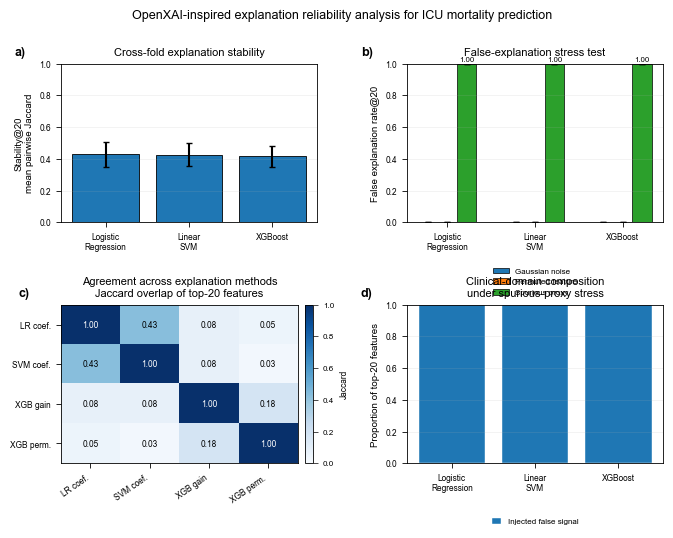

In [9]:
# ============================================================
# 7. Plot Figure 4
# ============================================================

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 7,
        "axes.titlesize": 8,
        "axes.labelsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "legend.fontsize": 5.8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "savefig.dpi": 600,
    }
)

fig_w = FIG_WIDTH_MM / 25.4
fig_h = FIG_HEIGHT_MM / 25.4

fig = plt.figure(figsize=(fig_w, fig_h))
gs = GridSpec(
    2,
    2,
    figure=fig,
    width_ratios=[1, 1],
    height_ratios=[1, 1],
    wspace=0.35,
    hspace=0.52,
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])


def panel_label(ax, label):
    ax.text(
        -0.18,
        1.11,
        label,
        transform=ax.transAxes,
        fontsize=9,
        fontweight="bold",
        va="top",
        ha="left",
    )


# ----------------------------
# Panel A
# ----------------------------
plot_models = ["Logistic Regression", "Linear SVM", "XGBoost"]
plot_labels = ["Logistic\nRegression", "Linear\nSVM", "XGBoost"]
x = np.arange(len(plot_models))

stab_vals = [
    float(stability_df.loc[stability_df["model"] == m, "stability_mean"].iloc[0])
    for m in plot_models
]
stab_err = [
    float(stability_df.loc[stability_df["model"] == m, "stability_std"].iloc[0])
    for m in plot_models
]

axA.bar(x, stab_vals, yerr=stab_err, capsize=2.5, linewidth=0.6, edgecolor="black")
axA.set_xticks(x)
axA.set_xticklabels(plot_labels)
axA.set_ylim(0, 1)
axA.set_ylabel(f"Stability@{TOP_K}\nmean pairwise Jaccard")
axA.set_title("Cross-fold explanation stability")
axA.grid(axis="y", alpha=0.25, linewidth=0.4)
panel_label(axA, "a)")


# ----------------------------
# Panel B: grouped stress-test FER
# ----------------------------
if "stress_type" in fer_summary.columns:
    stress_order = [s for s in ["Gaussian noise", "Permuted feature", "Spurious proxy"] if s in fer_summary["stress_type"].unique()]
else:
    stress_order = ["Noise injection"]
    fer_summary = fer_summary.copy()
    fer_summary["stress_type"] = "Noise injection"

bar_width = 0.22 if len(stress_order) >= 3 else 0.28
offsets = np.linspace(
    -bar_width * (len(stress_order) - 1) / 2,
    bar_width * (len(stress_order) - 1) / 2,
    len(stress_order),
)

max_fer = 0.0

for offset, stress_type in zip(offsets, stress_order):
    vals = []
    errs = []

    for model in plot_models:
        sub = fer_summary[
            (fer_summary["model"] == model)
            & (fer_summary["stress_type"] == stress_type)
        ]

        if len(sub) == 0:
            vals.append(0.0)
            errs.append(0.0)
        else:
            vals.append(float(sub["fer_mean"].iloc[0]))
            errs.append(float(0.0 if pd.isna(sub["fer_std"].iloc[0]) else sub["fer_std"].iloc[0]))

    max_fer = max(max_fer, max(vals) if vals else 0.0)

    axB.bar(
        x + offset,
        vals,
        width=bar_width,
        yerr=errs,
        capsize=2.0,
        linewidth=0.5,
        edgecolor="black",
        label=stress_type,
    )

    for xi, val in zip(x + offset, vals):
        if val > 0:
            axB.text(xi, val + 0.01, f"{val:.2f}", ha="center", va="bottom", fontsize=5.6)

axB.set_xticks(x)
axB.set_xticklabels(plot_labels)
axB.set_ylim(0, max(0.25, min(1.0, max_fer + 0.15)))
axB.set_ylabel(f"False explanation rate@{TOP_K}")
axB.set_title("False-explanation stress test")
axB.grid(axis="y", alpha=0.25, linewidth=0.4)
axB.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.24),
    ncol=1,
    frameon=False,
)
panel_label(axB, "b)")


# ----------------------------
# Panel C
# ----------------------------
im = axC.imshow(agreement_mat.values, vmin=0, vmax=1, aspect="auto", cmap="Blues")

axC.set_xticks(np.arange(len(methods)))
axC.set_yticks(np.arange(len(methods)))
axC.set_xticklabels(methods, rotation=35, ha="right")
axC.set_yticklabels(methods)
axC.set_title(f"Agreement across explanation methods\nJaccard overlap of top-{TOP_K} features")

for i in range(len(methods)):
    for j in range(len(methods)):
        val = agreement_mat.values[i, j]
        text_color = "white" if val > 0.55 else "black"
        axC.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=6, color=text_color)

cbar = fig.colorbar(im, ax=axC, fraction=0.046, pad=0.03)
cbar.ax.tick_params(labelsize=5.8, width=0.5)
cbar.set_label("Jaccard", fontsize=6)

panel_label(axC, "c)")


# ----------------------------
# Panel D: domain composition under spurious-proxy stress if available
# ----------------------------
domain_order = [
    "Renal",
    "Cardiovascular",
    "Respiratory",
    "Metabolic / acid-base",
    "Hematologic",
    "Neurological",
    "Static / demographic",
    "Measurement process",
    "Injected false signal",
    "Other clinical",
]

if "stress_type" in domain_summary.columns and "Spurious proxy" in domain_summary["stress_type"].unique():
    domain_for_plot = domain_summary[domain_summary["stress_type"] == "Spurious proxy"].copy()
    domain_title = "Clinical-domain composition\nunder spurious-proxy stress"
else:
    domain_for_plot = domain_summary.copy()
    domain_title = "Clinical-domain composition\nof explanations"

domain_pivot = (
    domain_for_plot.pivot_table(
        index="model",
        columns="domain",
        values="proportion",
        aggfunc="mean",
    )
    .reindex(plot_models)
    .fillna(0)
)

for domain in domain_order:
    if domain not in domain_pivot.columns:
        domain_pivot[domain] = 0

domain_pivot = domain_pivot[domain_order]

bottom = np.zeros(len(plot_models))
for domain in domain_order:
    vals = domain_pivot[domain].values
    if np.all(vals == 0):
        continue

    axD.bar(
        x,
        vals,
        bottom=bottom,
        label=domain,
        linewidth=0.3,
        edgecolor="white",
    )
    bottom += vals

axD.set_xticks(x)
axD.set_xticklabels(plot_labels)
axD.set_ylim(0, 1)
axD.set_ylabel(f"Proportion of top-{TOP_K} features")
axD.set_title(domain_title)
axD.grid(axis="y", alpha=0.25, linewidth=0.4)

axD.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=2,
    frameon=False,
    handlelength=1.2,
    columnspacing=0.8,
)

panel_label(axD, "d)")


# ----------------------------
# Final formatting
# ----------------------------
for ax in [axA, axB, axC, axD]:
    for spine in ax.spines.values():
        spine.set_linewidth(0.6)

fig.suptitle(
    "OpenXAI-inspired explanation reliability analysis for ICU mortality prediction",
    fontsize=9,
    y=0.995,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.90,
    bottom=0.20,
)

fig.savefig(FIG_PNG, dpi=600, bbox_inches="tight")
fig.savefig(FIG_PDF, bbox_inches="tight")

print("\nSaved:")
print(FIG_PNG)
print(FIG_PDF)

print("\nSaved result tables to:")
print(RESULT_DIR.resolve())


## Notes for manuscript interpretation

Use this figure as the **main Figure 4** because it directly evaluates explanation reliability rather than only showing SHAP/permutation plots.

Suggested figure legend:

> Figure 4. OpenXAI-inspired explanation reliability analysis for ICU mortality prediction.  
> a) Cross-fold explanation stability measured by pairwise Jaccard similarity of top-ranked features across five cross-validation folds.  
> b) False explanation stress test using three injected feature families: Gaussian noise, permuted real-feature controls, and train-only spurious proxy features. False explanation rate was defined as the proportion of injected false-signal features appearing among the top-k explanation features.  
> c) Agreement across explanation methods measured by top-k Jaccard overlap among logistic regression coefficients, linear SVM coefficients, XGBoost gain importance, and XGBoost permutation importance.  
> d) Clinical-domain composition of top-ranked explanation features under the spurious-proxy stress test, separating physiological domains, measurement-process variables, and injected false-signal features.

Interpretation note:

> Gaussian and permuted features are negative controls. Spurious proxy features are a positive-control false signal because they are deliberately correlated with the training label but random in the external/test cohort. This tests whether model explanations can reveal vulnerability to false inferences rather than only reporting attractive post-hoc feature rankings.
